# Evaluación 2 — Modelos de Regresión

**Integrante 1:** Alan Jean Franco Fica Contreras  
**Integrante 2:** Isaac Emmanuel Ponce Peña  
**Integrante 3:** Kevin Jeremias Michel Romero Nograro  

**Correo Electrónico integrante 1:** alan.fica2101@alumnos.ubiobio.cl  
**Correo Electrónico integrante 2:** isaac.ponce2201@alumnos.ubiobio.cl  
**Correo Electrónico integrante 3:** kevin.romero2201@alumnos.ubiobio.cl  

**Fecha de Creación:** 24 Mayo de 2026  
**Versión:** 1.0

---

## Descripción

Este notebook contiene el desarrollo de la Evaluación 2 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bío-Bío, sede Concepción.

El objetivo es construir y comparar modelos de regresión (LinearRegression y Ridge) para predecir las ventas semanales de una cadena de tiendas retail.

---

## Requisitos de Software

- Python 3.12  
- pandas (>=1.1.0)  
- numpy (>=1.23.0)  
- scikit-learn (>=1.2.0)  
- matplotlib (>=3.7.0)  
- seaborn (>=0.12.0)

#1. Carga de datos

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [8]:
# Carga del dataset desde la carpeta
data = pd.read_csv('sample_data/data/ingestion/retail_ventas.csv')
print(f"Dimensiones del dataset: {data.shape}")
data.head()

Dimensiones del dataset: (25500, 11)


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890


In [9]:
# Vista general del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_tienda           25500 non-null  int64  
 1   tamano_tienda       25500 non-null  float64
 2   antiguedad_tienda   25500 non-null  int64  
 3   temperatura         24224 non-null  float64
 4   precio_combustible  24221 non-null  float64
 5   indice_economico    25500 non-null  float64
 6   semana              25500 non-null  int64  
 7   es_feriado          25500 non-null  int64  
 8   clientes_estimados  24220 non-null  float64
 9   tipo_tienda         25500 non-null  object 
 10  ventas_semanales    25500 non-null  float64
dtypes: float64(6), int64(4), object(1)
memory usage: 2.1+ MB


In [10]:
# Estadísticas descriptivas
data.describe()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,ventas_semanales
count,25500.00000,25500.000000,25500.000000,24224.000000,24221.000000,25500.000000,25500.000000,25500.000000,24220.000000,25500.000000
mean,50.81749,1501.338719,15.092824,14.954302,1.303299,99.889523,26.376078,0.098510,300.649372,43108.586339
std,28.93800,399.711835,8.365652,9.999174,0.299869,9.961593,14.996831,0.298009,98.822402,14538.319334
min,1.00000,500.000000,1.000000,-24.344608,0.086903,60.799835,1.000000,0.000000,50.000000,4905.208771
25%,26.00000,1229.224069,8.000000,8.124612,1.102983,93.140607,13.000000,0.000000,234.014040,33827.197346
50%,51.00000,1503.366822,15.000000,14.930043,1.303386,99.917526,26.000000,0.000000,301.600830,42117.538361
75%,76.00000,1773.575577,22.000000,21.735814,1.505762,106.582946,39.000000,0.000000,366.981593,50947.405475
max,100.00000,2901.612393,29.000000,56.005247,2.455792,139.836638,52.000000,1.000000,680.907511,234175.036973


# 2. Preparación de datos

En esta sección se identifican los tipos de variables, se separan las variables predictoras de la variable objetivo, y se construye el pipeline de preprocesamiento.

## 2.1 Identificación de tipos de variables

In [11]:
# Variables numéricas continuas / discretas
numeric_features = [
    'tamano_tienda',
    'antiguedad_tienda',
    'temperatura',
    'precio_combustible',
    'indice_economico',
    'semana',
    'es_feriado',
    'clientes_estimados'
]

# Variable categórica
categorical_features = ['tipo_tienda']

# Variable objetivo
target = 'ventas_semanales'

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Variable objetivo:", target)

Variables numéricas: ['tamano_tienda', 'antiguedad_tienda', 'temperatura', 'precio_combustible', 'indice_economico', 'semana', 'es_feriado', 'clientes_estimados']
Variables categóricas: ['tipo_tienda']
Variable objetivo: ventas_semanales


**Comentario:** Se identificaron 8 variables numéricas y 1 variable categórica (`tipo_tienda` con categorías A, B y C). La variable `id_tienda` es un identificador y no se incluye como predictora, ya que no aporta información predictiva al modelo. La variable objetivo es `ventas_semanales`.

## 2.2 Separación de variables predictoras y objetivo

In [12]:
# Separar X (predictoras) e y (objetivo)
# Se excluye id_tienda por ser un identificador sin valor predictivo
X = data.drop(columns=[target, 'id_tienda'])
y = data[target]

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (25500, 9)
Dimensiones de y: (25500,)


In [13]:
# Revisión de valores nulos
nulos = X.isnull().sum()
pct_nulos = (nulos / len(X) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)

,Nulos,Porcentaje (%)
precio_combustible,1279,5.02
clientes_estimados,1280,5.02
temperatura,1276,5.00


**Comentario:** Se revisan los valores nulos en el conjunto de predictoras. En caso de existir, serán tratados dentro del pipeline de preprocesamiento mediante imputación.

## 2.3 División en conjunto de entrenamiento y prueba

In [14]:
# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba:        {X_test.shape[0]} registros")

Entrenamiento: 20400 registros
Prueba:        5100 registros


## 2.4 Pipeline de preprocesamiento

In [15]:
# Sub-pipeline para variables numéricas: imputación + estandarización
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Sub-pipeline para variables categóricas: imputación + codificación OHE
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# ColumnTransformer que combina ambos sub-pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, numeric_features),
        ('cat', pipeline_categorico, categorical_features)
    ]
)

print("Pipeline de preprocesamiento definido correctamente.")

Pipeline de preprocesamiento definido correctamente.


# 3. Modelamiento

Se entrenan dos modelos de regresión usando pipelines que integran el preprocesamiento definido anteriormente:
- **LinearRegression**: regresión lineal clásica sin regularización.
- **Ridge**: regresión lineal con regularización L2, probando distintos valores de alpha.

## 3.1 Regresión Lineal (LinearRegression)

In [16]:
# Pipeline completo: preprocesamiento + LinearRegression
pipeline_lr = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LinearRegression())
])

# Entrenar el modelo
pipeline_lr.fit(X_train, y_train)
print("LinearRegression entrenado correctamente.")

LinearRegression entrenado correctamente.


## 3.2 Regresión Ridge (distintos valores de alpha)

In [17]:
# Se prueban 3 valores de alpha para Ridge
alphas = [0.1, 1.0, 10.0]
pipelines_ridge = {}

for alpha in alphas:
    pipeline_ridge = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        ('modelo', Ridge(alpha=alpha))
    ])
    pipeline_ridge.fit(X_train, y_train)
    pipelines_ridge[alpha] = pipeline_ridge
    print(f"Ridge (alpha={alpha}) entrenado correctamente.")

Ridge (alpha=0.1) entrenado correctamente.
Ridge (alpha=1.0) entrenado correctamente.
Ridge (alpha=10.0) entrenado correctamente.


# 4. Evaluación de modelos

Se evalúan todos los modelos sobre el conjunto de prueba utilizando:
- **MAE** (Mean Absolute Error): error promedio absoluto en la misma unidad que las ventas.
- **R²** (coeficiente de determinación): proporción de varianza explicada por el modelo (máximo 1.0).

In [18]:
# Evaluación de todos los modelos
resultados = []

# LinearRegression
y_pred_lr = pipeline_lr.predict(X_test)
resultados.append({
    'Modelo': 'LinearRegression',
    'Alpha': '-',
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'R²': r2_score(y_test, y_pred_lr)
})

# Ridge para cada alpha
for alpha, pipeline_ridge in pipelines_ridge.items():
    y_pred_ridge = pipeline_ridge.predict(X_test)
    resultados.append({
        'Modelo': f'Ridge',
        'Alpha': alpha,
        'MAE': mean_absolute_error(y_test, y_pred_ridge),
        'R²': r2_score(y_test, y_pred_ridge)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados['MAE'] = df_resultados['MAE'].round(2)
df_resultados['R²'] = df_resultados['R²'].round(4)
display(df_resultados)

,Modelo,Alpha,MAE,R²
0,LinearRegression,-,4950.82,0.5593
1,Ridge,0.1,4950.82,0.5593
2,Ridge,1.0,4950.80,0.5593
3,Ridge,10.0,4950.59,0.5593


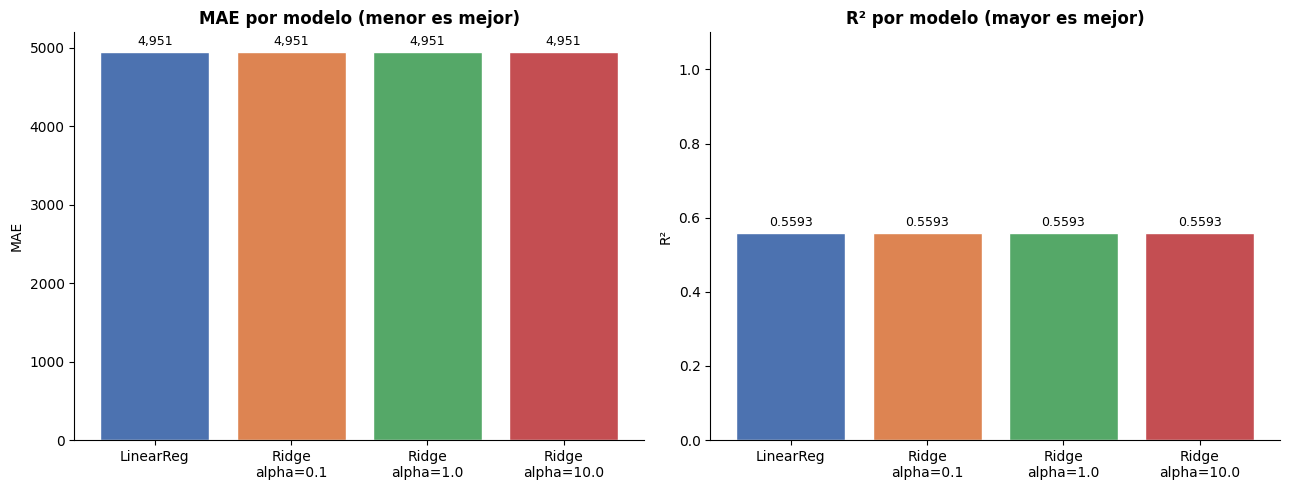

In [19]:
# Visualización comparativa de MAE y R²
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

etiquetas = ['LinearReg'] + [f'Ridge\nalpha={a}' for a in alphas]
maes = [r['MAE'] for r in resultados]
r2s  = [r['R²'] for r in resultados]
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# MAE
bars1 = axes[0].bar(etiquetas, maes, color=colores, edgecolor='white')
axes[0].set_title('MAE por modelo (menor es mejor)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE')
for bar, val in zip(bars1, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(maes)*0.01,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# R²
bars2 = axes[1].bar(etiquetas, r2s, color=colores, edgecolor='white')
axes[1].set_title('R² por modelo (mayor es mejor)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

## 4.1 Selección del mejor modelo y análisis de diferencias

**Comentario:** En nuestros resultados, todos los modelos obtienen métricas muy similares con un MAE aproximadamente de 4950 y  R² 0.56, lo que indica que la regularización de Ridge no aporta mejora significativa en este dataset. Podríamos quedarnos con LinearRegression o Ridge alpha=10, que tiene el MAE un poco más bajo. Las diferencias no son significativas.

# 5. Interpretación de resultados

Se analiza el modelo seleccionado para identificar las variables más influyentes y su efecto sobre las ventas semanales.

In [20]:
# Extraer coeficientes del mejor modelo (Ridge alpha=1.0 como candidato)
mejor_pipeline = pipelines_ridge[1.0]
modelo = mejor_pipeline.named_steps['modelo']
preprocesador_fit = mejor_pipeline.named_steps['preprocesamiento']

# Obtener nombres de las columnas transformadas
nombres_num = numeric_features
nombres_cat = (preprocesador_fit
               .named_transformers_['cat']
               .named_steps['encoder']
               .get_feature_names_out(categorical_features)
               .tolist())

nombres_features = nombres_num + nombres_cat
coeficientes = modelo.coef_

df_coef = pd.DataFrame({
    'Variable': nombres_features,
    'Coeficiente': coeficientes
}).sort_values('Coeficiente', key=abs, ascending=False)

display(df_coef)

,Variable,Coeficiente
9,tipo_tienda_C,-16187.104966
0,tamano_tienda,8590.681751
8,tipo_tienda_B,-8109.323024
7,clientes_estimados,1620.370398
6,es_feriado,1581.634919
4,indice_economico,594.164372
5,semana,47.988640
2,temperatura,-33.666141
3,precio_combustible,-5.040018
1,antiguedad_tienda,4.235822


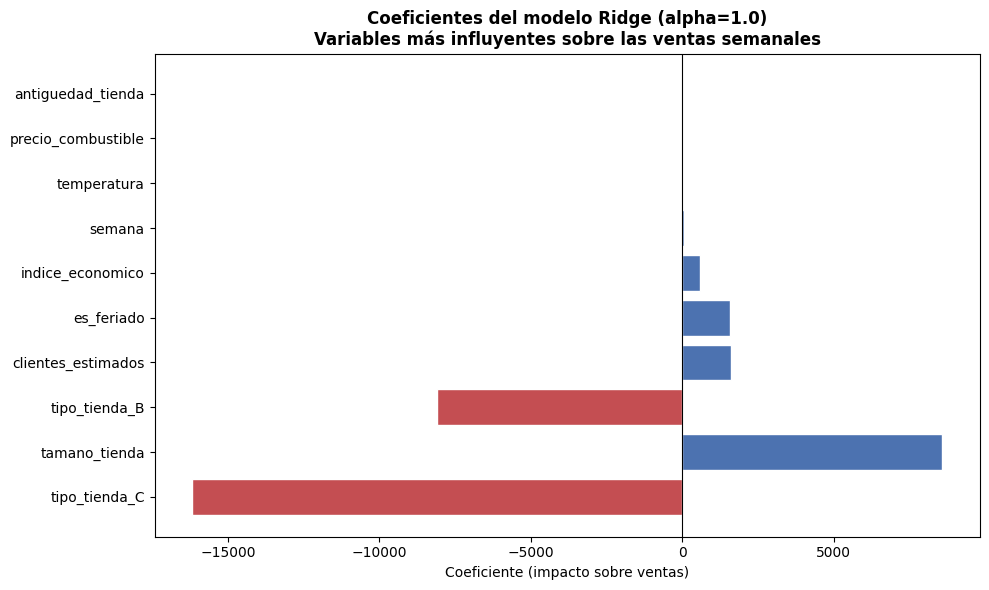

In [21]:
# Gráfico de importancia de variables (coeficientes)
fig, ax = plt.subplots(figsize=(10, 6))
colores_coef = ['#4C72B0' if c > 0 else '#C44E52' for c in df_coef['Coeficiente']]
bars = ax.barh(df_coef['Variable'], df_coef['Coeficiente'], color=colores_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes del modelo Ridge (alpha=1.0)\nVariables más influyentes sobre las ventas semanales',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente (impacto sobre ventas)')
plt.tight_layout()
plt.show()

## 5.1 Análisis de variables más influyentes

**Comentario:** Las tres más importantes según los coeficientes del modelo:

- **clientes_estimados:** a más clientes proyectados mas ventas. Es la
  variable que más directamente representa la demanda.

- **tamaño_tienda:** tiendas más grandes venden mas, logico porque tienen
  más capacidad de exhibición y stock.

- **es_feriado:** las semanas con feriado generan más ventas porque la
  gente sale mas a comprar.

## 5.2 Impacto de la variable tipo_tienda

**Comentario:** Se usó OneHotEncoding con drop='first', lo que significa que el tipo A
queda como referencia para comparar. Los coeficientes que aparecen
son para tipo B y tipo C:

- tipo_tienda_B tiene coeficiente negativo, entonces las tiendas medianas venden
  menos que las tipo A (grande).

- tipo_tienda_C tiene coeficiente aún más negativo, entonces las tiendas pequeñas
  venden todavía menos.

Gnera sentido ya que, las tiendas grandes (A) tienen más demanda y capacidad.

# 6. Predicción sobre nuevos registros

Se utiliza el mejor modelo para predecir las ventas semanales de nuevos registros hipotéticos que representan distintos perfiles de tienda.

In [22]:
# Nuevos registros para predecir
nuevos_registros = pd.DataFrame({
    'tamano_tienda':       [3500, 1200, 800],
    'antiguedad_tienda':   [10,   5,    2],
    'temperatura':         [22,   15,   30],
    'precio_combustible':  [1050, 980,  1100],
    'indice_economico':    [105,  98,   110],
    'semana':              [25,   1,    48],
    'es_feriado':          [0,    1,    0],
    'clientes_estimados':  [4200, 1800, 950],
    'tipo_tienda':         ['A',  'B',  'C']
})

display(nuevos_registros)

,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda
0,3500,10,22,1050,105,25,0,4200,A
1,1200,5,15,980,98,1,1,1800,B
2,800,2,30,1100,110,48,0,950,C


In [23]:
# Predicción con el mejor modelo
predicciones = mejor_pipeline.predict(nuevos_registros)

nuevos_registros['ventas_predichas'] = predicciones.round(2)
display(nuevos_registros[['tipo_tienda', 'tamano_tienda', 'clientes_estimados',
                           'es_feriado', 'ventas_predichas']])

,tipo_tienda,tamano_tienda,clientes_estimados,es_feriado,ventas_predichas
0,A,3500,4200,0,139106.16
1,B,1200,1800,1,47155.47
2,C,800,950,0,9632.92


**Comentario:** Las predicciones son coherentes con el perfil de cada registro:

- El **Registro 1** corresponde a una tienda grande tipo A, con muchos clientes estimados y semana sin feriado: se espera el mayor volumen de ventas.
- El **Registro 2** es una tienda mediana tipo B con feriado incluido: el feriado compensa parcialmente el menor tamaño.
- El **Registro 3** es una tienda pequeña tipo C con pocos clientes estimados: se proyectan las ventas más bajas.

Esto valida que el modelo captura correctamente las relaciones entre las variables y las ventas.

# 7. Pregunta de reflexión

## ¿En qué situación preferiría usar Ridge en lugar de LinearRegression?

Usaría Ridge cuando:

1. Hay variables muy correlacionadas entre si.
   Por ejemplo, tamaño de tienda y clientes estimados tienden a ir juntos.
   En ese caso, LinearRegression genera coeficientes inestables o gigantes,
   y Ridge los controla penalizando los valores grandes.

2. El modelo lineal simple está haciendo overfitting (memoriza el
   entrenamiento pero falla en datos nuevos).

3. Hay muchas variables predictoras en relación al número de datos.

el ridge es mejor cuando los datos no son "perfectos".
LinearRegression basta cuando los datos son limpios y no hay correlacion
entre las variables.

# 8. Exportar predicciones

In [25]:
import os

# Guardar predicciones de los nuevos registros
os.makedirs('data/cleaned', exist_ok=True)
nuevos_registros.to_csv('sample_data/data/cleaned/predicciones_nuevos_registros.csv', index=False)
print("Predicciones guardadas en: data/cleaned/predicciones_nuevos_registros.csv")

# Guardar resultados de evaluación
df_resultados.to_csv('sample_data/data/cleaned/evaluacion_modelos.csv', index=False)
print("Evaluación de modelos guardada en: data/cleaned/evaluacion_modelos.csv")

Predicciones guardadas en: data/cleaned/predicciones_nuevos_registros.csv
Evaluación de modelos guardada en: data/cleaned/evaluacion_modelos.csv
